In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
data = pd.read_csv('housing.csv')

In [3]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
print("Data shape:", data.shape)

Data shape: (20640, 10)


In [5]:
print("Data columns:", data.columns.tolist())
print("Data types:\n",data.dtypes)


Data columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
Data types:
 longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


In [6]:
print("Data Info:")
data.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
print("Missing values in each column:\n", data.isnull().sum())
print("Number of duplicate rows:", data.duplicated().sum())
print("Unique values in 'ocean proximity':",data['ocean_proximity'].unique())

Missing values in each column:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Number of duplicate rows: 0
Unique values in 'ocean proximity': ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


In [8]:
print("Number of unique values on 'ocean proximity':",data['ocean_proximity'].nunique())
data['ocean_proximity'].value_counts()

Number of unique values on 'ocean proximity': 5


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [9]:
print("Summary statistics for numerical columns:\n")
data.describe()

Summary statistics for numerical columns:



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [28]:
print("Dropping nan values\n")
data.dropna(inplace=True)
print("Data shape after dropping nan values:", data.shape)

Dropping nan values

Data shape after dropping nan values: (20433, 10)


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 1.7 MB


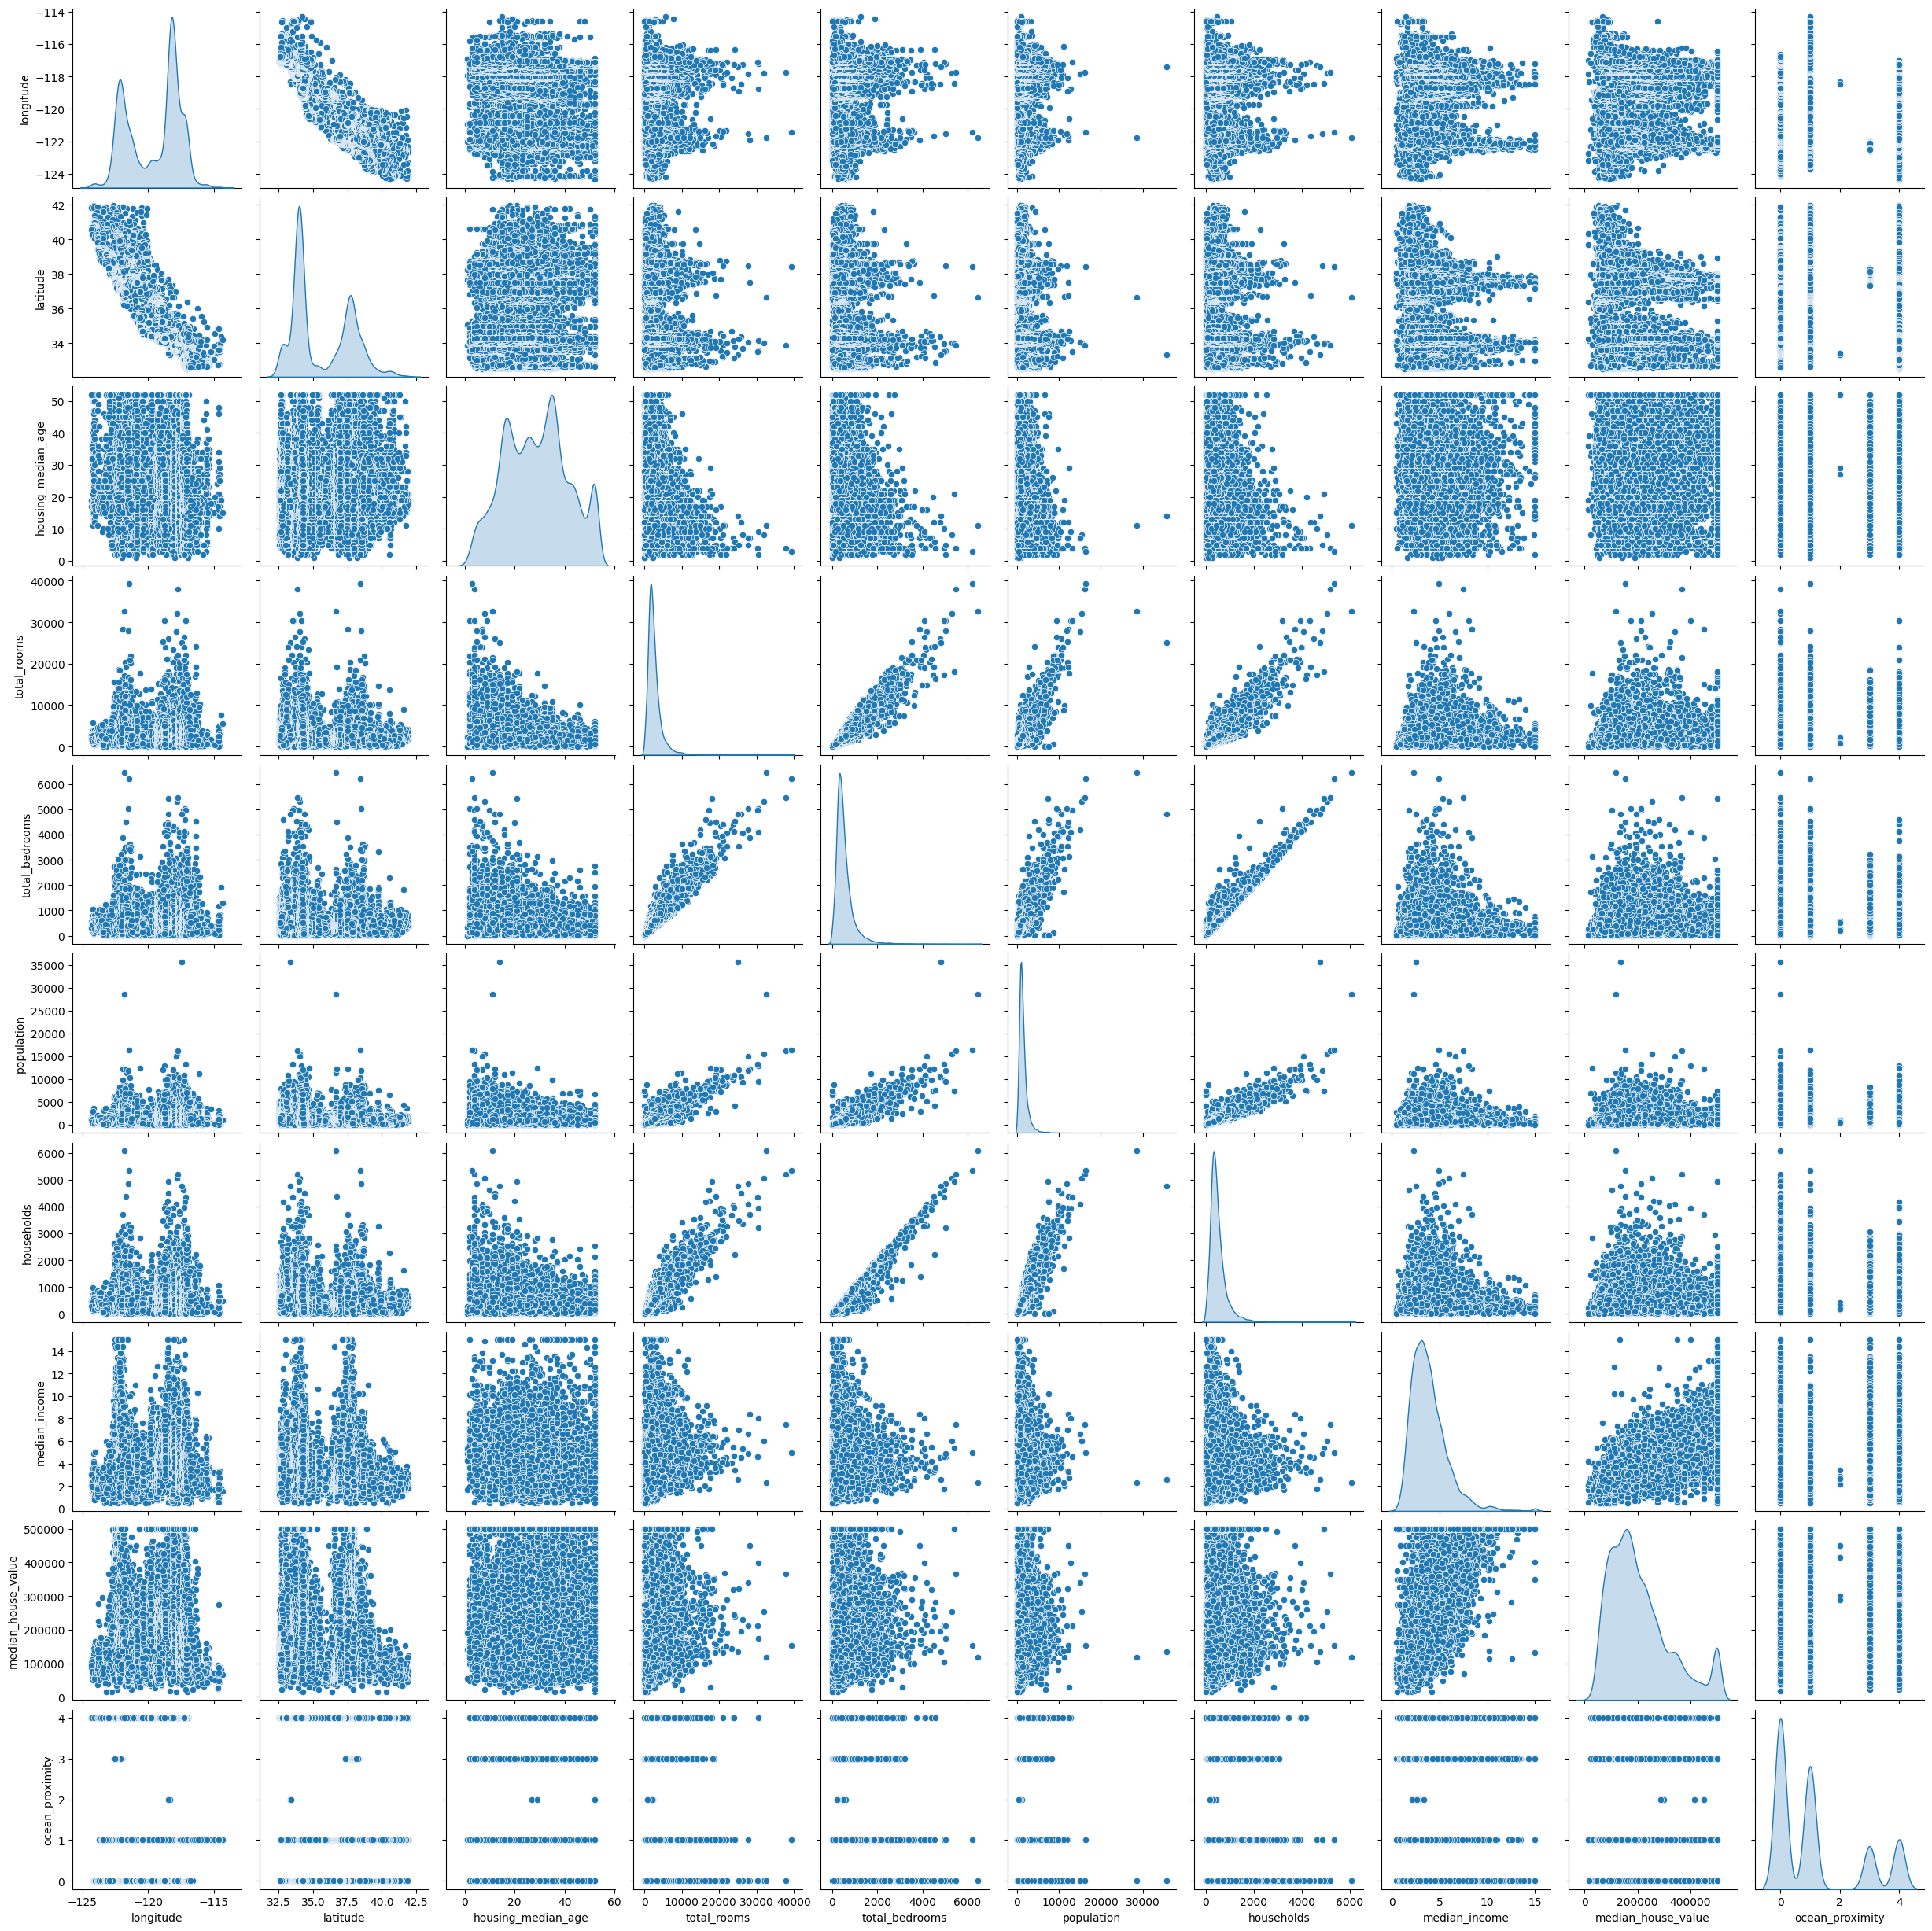

In [30]:
sns.pairplot(data,diag_kind='kde')

In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['ocean_proximity'] = le.fit_transform(data['ocean_proximity'])

In [32]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


<Axes: >

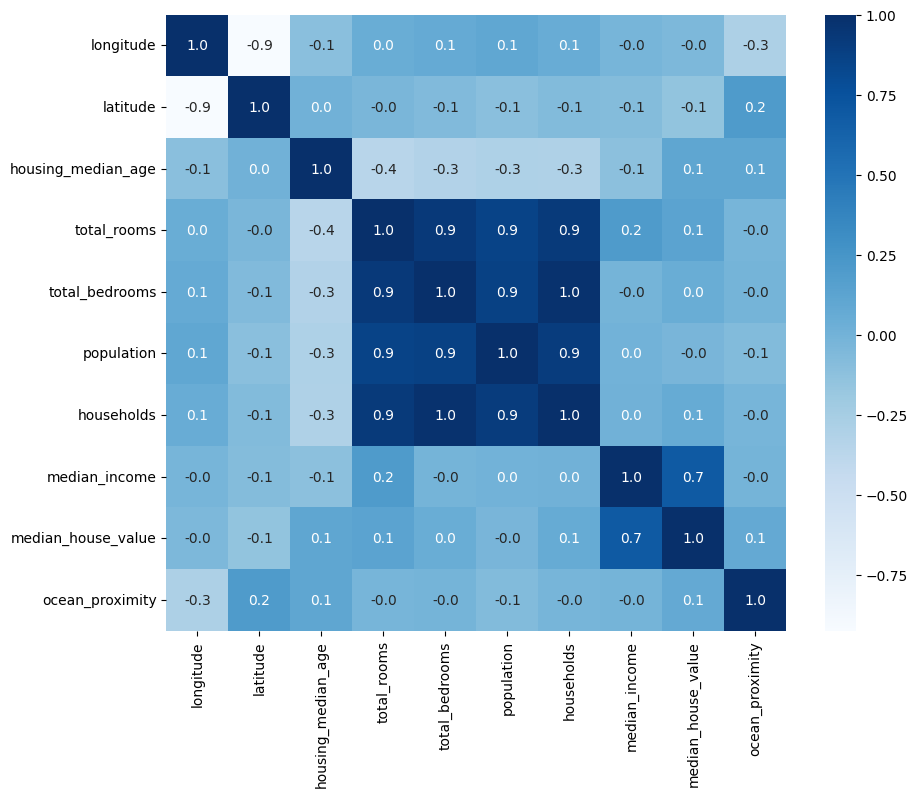

In [33]:
corr_matrix = data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cbar=True, fmt =  '.1f', annot=True, cmap='Blues')

<Axes: xlabel='median_house_value', ylabel='Count'>

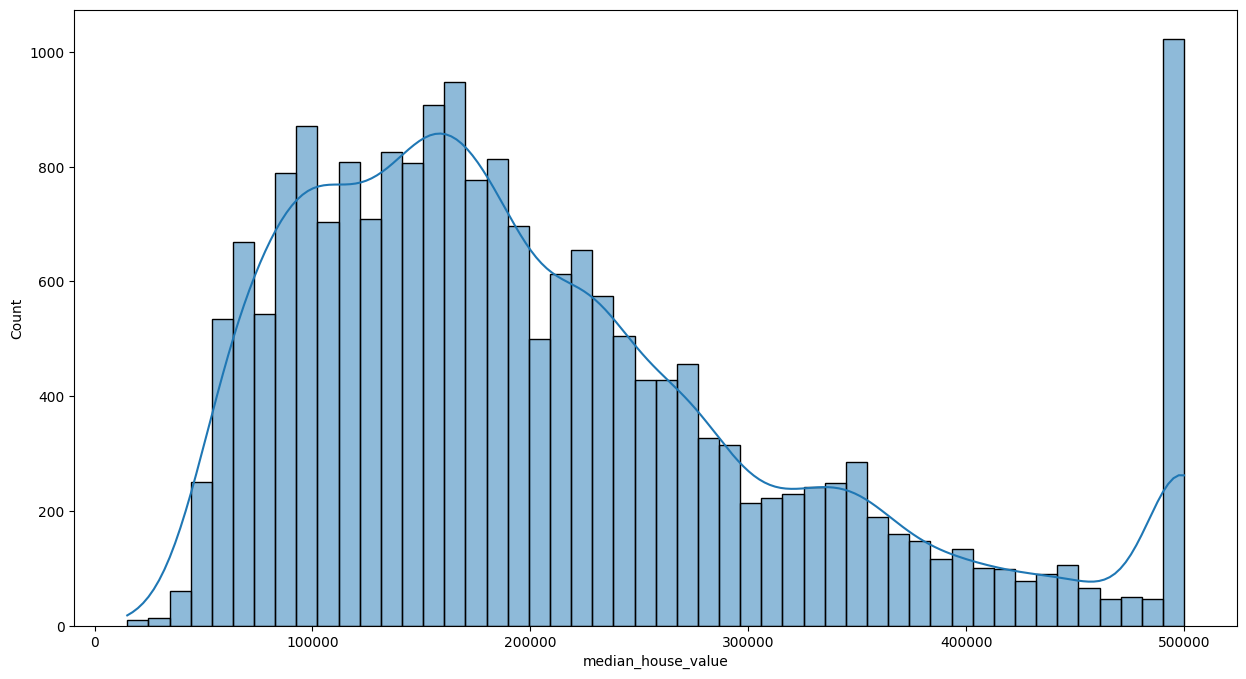

In [42]:
plt.figure(figsize=(15,8))
sns.histplot(data['median_house_value'],bins=50, kde=True)

<Axes: xlabel='ocean_proximity', ylabel='median_house_value'>

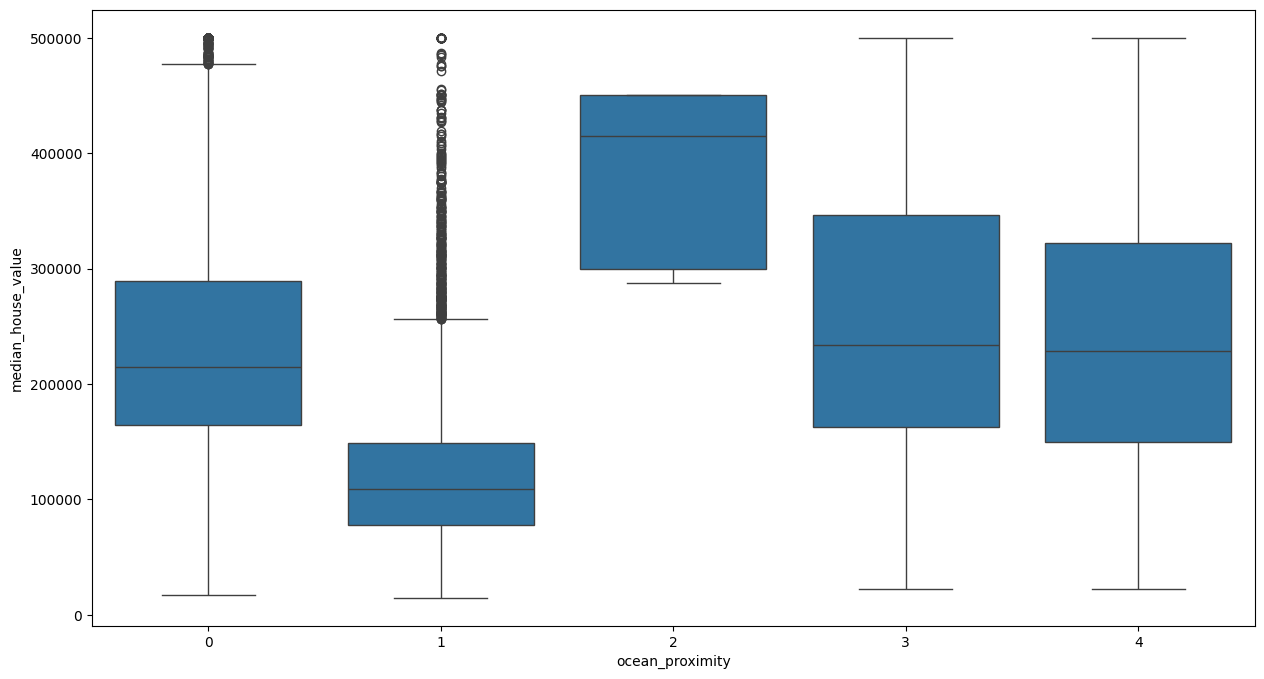

In [43]:
plt.figure(figsize=(15,8))
sns.boxplot(x=data['ocean_proximity'],y=data['median_house_value'])

<Axes: xlabel='median_income', ylabel='median_house_value'>

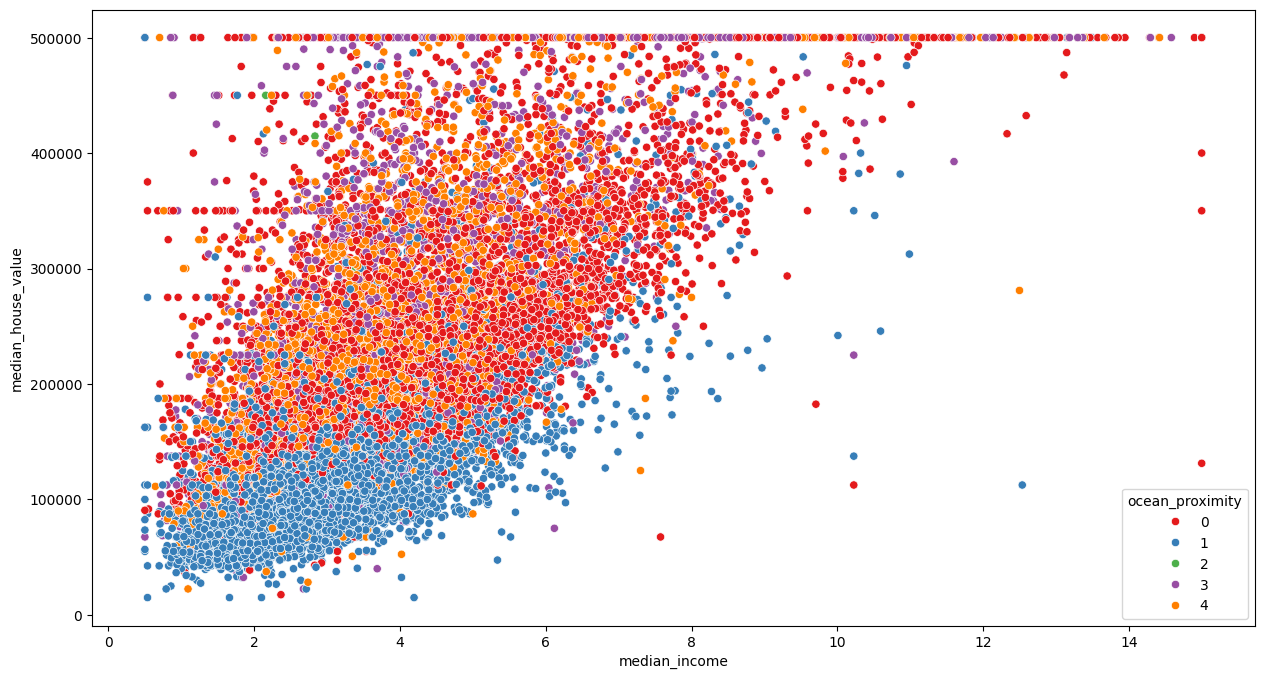

In [44]:
plt.figure(figsize=(15,8))
sns.scatterplot(x=data['median_income'],y=data['median_house_value'],hue=data['ocean_proximity'],palette='Set1')

<Axes: xlabel='latitude', ylabel='longitude'>

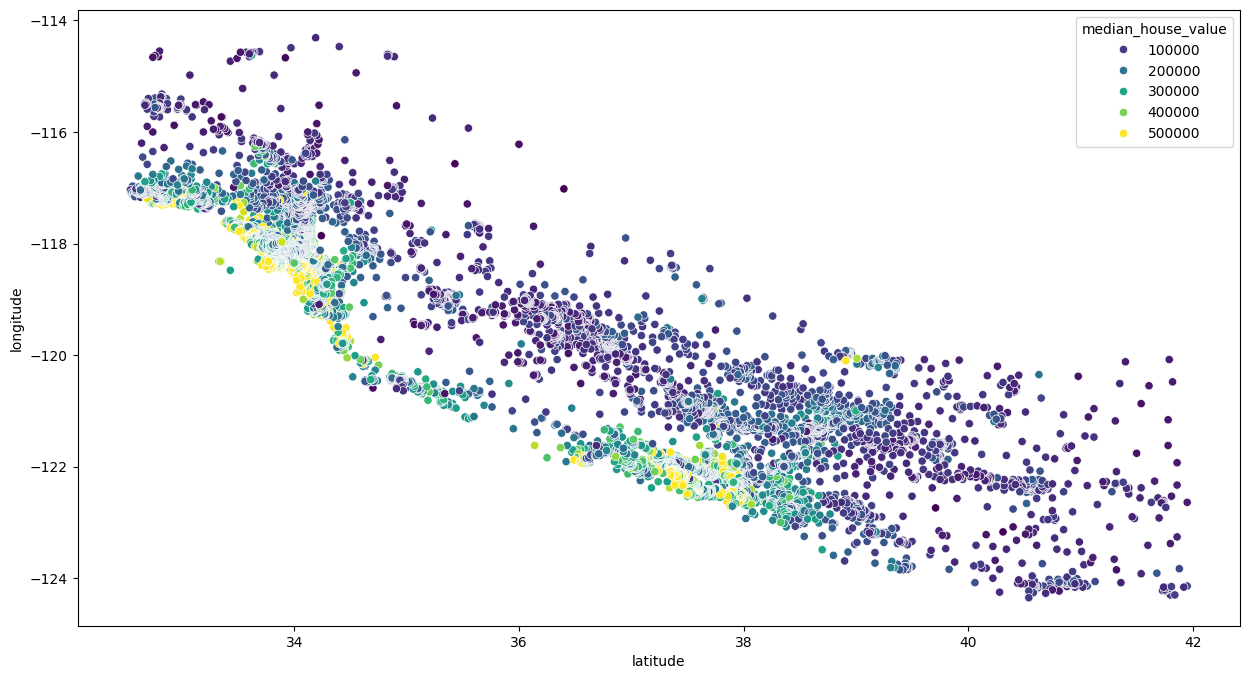

In [46]:
plt.figure(figsize=(15,8))
sns.scatterplot(x=data['latitude'],y=data['longitude'],hue=data['median_house_value'],palette='viridis')

In [47]:
data['bedroom_ratio'] = data['total_bedrooms'] / data['total_rooms']
data['household_size'] = data['population'] / data['households']
data['income_per_room'] = data['median_income'] / data['total_rooms']
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,bedroom_ratio,household_size,income_per_room
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3,0.146591,2.555556,0.009460
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3,0.155797,2.109842,0.001169
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3,0.129516,2.802260,0.004947
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3,0.184458,2.547945,0.004429
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3,0.172096,2.181467,0.002364


<Axes: >

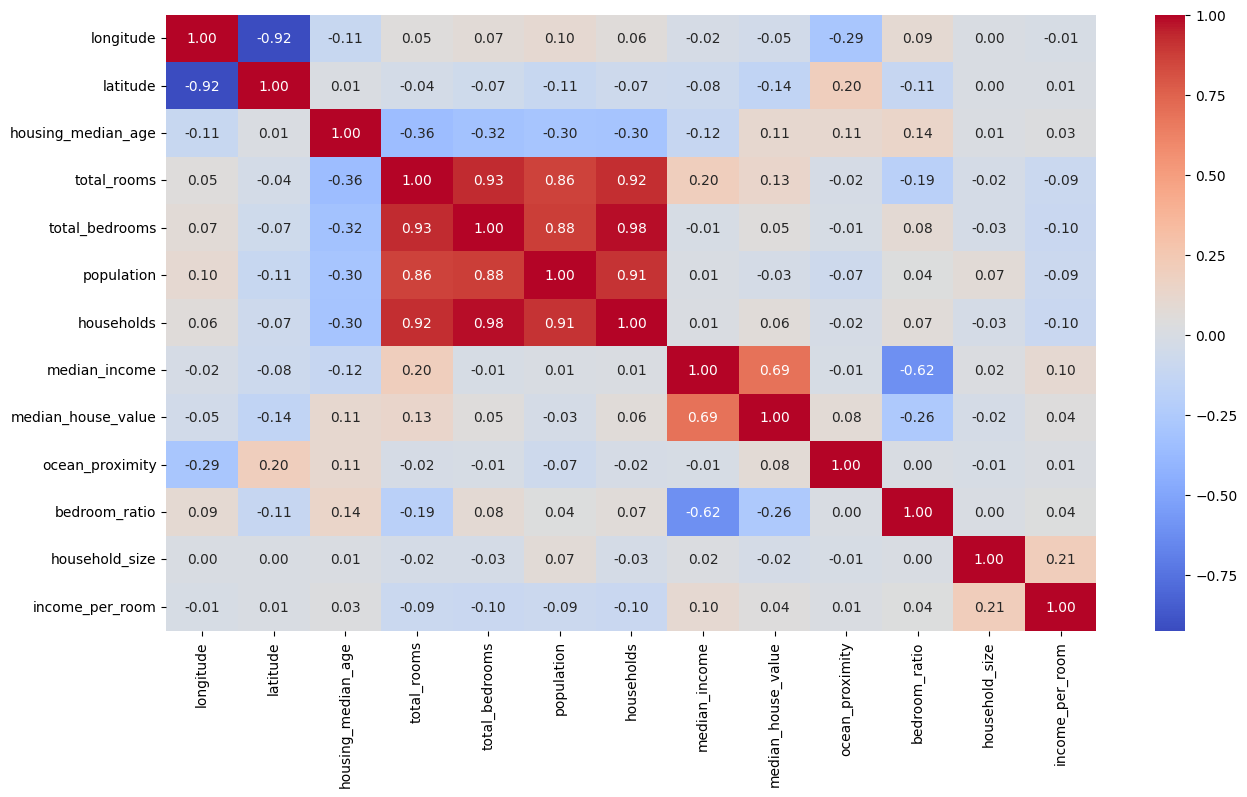

In [48]:
plt.figure(figsize=(15,8))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm',fmt='.2f')

In [49]:
X = data.drop('median_house_value',axis=1)
y = data['median_house_value']

In [50]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,bedroom_ratio,household_size,income_per_room
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,3,0.146591,2.555556,0.009460
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3,0.155797,2.109842,0.001169
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3,0.129516,2.802260,0.004947
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3,0.184458,2.547945,0.004429
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3,0.172096,2.181467,0.002364


In [51]:
y.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [53]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [73]:
dt = DecisionTreeRegressor(max_depth=5,random_state=42)
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
xgb = XGBRegressor(n_estimators=100, max_depth=5, random_state=42)

In [74]:
models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb
}

In [75]:
def train_predict_model(X_train, y_train, X_test_scaled, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test_scaled)
    return model, y_pred

In [95]:
def evaluate_model(y_test,y_pred):
    print("R2 score:", r2_score(y_test,y_pred))
    print("MSE:", mean_squared_error(y_test,y_pred))
    print("MAE:", mean_absolute_error(y_test,y_pred))
    return

In [96]:
for name,model in models.items():
    print("Training and Evaluating model:",name)
    trained_model, y_pred = train_predict_model(X_train_scaled, y_train, X_test_scaled, model)
    evaluate_model(y_test,y_pred)
    print("\n")

Training and Evaluating model: Decision Tree
R2 score: 0.6241996938945563
MSE: 5139137125.444382
MAE: 51115.02244581279


Training and Evaluating model: Random Forest
R2 score: 0.6727087763217263
MSE: 4475766653.487494
MAE: 47526.014740593106


Training and Evaluating model: XGBoost
R2 score: 0.8275859260130631
MSE: 2357793631.830537
MAE: 32006.044757003914




In [97]:
import pickle
pickle.dump(xgb,open('xgb_model.pkl','wb'))